In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

base_path = r"/Users/kdt_0900_lyn/data_analysis/resource/dataset"
file_name = r"hr_employee_attrition.csv"

file_path = os.path.join(base_path, file_name)

In [19]:


promo_df = pd.read_csv(file_path)
promo_df

,Attrition,Age,Gender,MaritalStatus,Education,Department,JobRole,BusinessTravel,OverTime,DistanceFromHome,MonthlyIncome,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,YearsAtCompany,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,PerformanceRating,YearsSinceLastPromotion
0,Yes,41,Female,Single,2,Sales,Sales Executive,Travel_Rarely,Yes,1,5993,11,0,8,6,2,4,1,3,0
1,No,49,Male,Married,1,Research & Development,Research Scientist,Travel_Frequently,No,8,5130,23,1,10,10,3,2,3,4,1
2,Yes,37,Male,Single,2,Research & Development,Laboratory Technician,Travel_Rarely,Yes,2,2090,15,0,7,0,4,3,3,3,0
3,No,33,Female,Married,4,Research & Development,Research Scientist,Travel_Frequently,Yes,3,2909,11,0,8,8,4,3,3,3,3
4,No,27,Male,Married,1,Research & Development,Laboratory Technician,Travel_Rarely,No,2,3468,12,1,6,2,1,2,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,No,36,Male,Married,2,Research & Development,Laboratory Technician,Travel_Frequently,No,23,2571,17,1,17,5,3,4,3,3,0
1466,No,39,Male,Married,1,Research & Development,Healthcare Representative,Travel_Rarely,No,6,9991,15,1,9,7,4,1,3,3,1
1467,No,27,Male,Married,3,Research & Development,Manufacturing Director,Travel_Rarely,Yes,4,6142,20,1,6,6,2,2,3,4,0
1468,No,49,Male,Married,3,Sales,Sales Executive,Travel_Frequently,No,2,5390,14,0,17,9,4,2,2,3,0


In [22]:
promo_df

,Attrition,Age,Gender,MaritalStatus,Education,Department,JobRole,BusinessTravel,OverTime,DistanceFromHome,MonthlyIncome,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,YearsAtCompany,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,PerformanceRating,YearsSinceLastPromotion
0,Yes,41,Female,Single,2,Sales,Sales Executive,Travel_Rarely,Yes,1,5993,11,0,8,6,2,4,1,3,0
1,No,49,Male,Married,1,Research & Development,Research Scientist,Travel_Frequently,No,8,5130,23,1,10,10,3,2,3,4,1
2,Yes,37,Male,Single,2,Research & Development,Laboratory Technician,Travel_Rarely,Yes,2,2090,15,0,7,0,4,3,3,3,0
3,No,33,Female,Married,4,Research & Development,Research Scientist,Travel_Frequently,Yes,3,2909,11,0,8,8,4,3,3,3,3
4,No,27,Male,Married,1,Research & Development,Laboratory Technician,Travel_Rarely,No,2,3468,12,1,6,2,1,2,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,No,36,Male,Married,2,Research & Development,Laboratory Technician,Travel_Frequently,No,23,2571,17,1,17,5,3,4,3,3,0
1466,No,39,Male,Married,1,Research & Development,Healthcare Representative,Travel_Rarely,No,6,9991,15,1,9,7,4,1,3,3,1
1467,No,27,Male,Married,3,Research & Development,Manufacturing Director,Travel_Rarely,Yes,4,6142,20,1,6,6,2,2,3,4,0
1468,No,49,Male,Married,3,Sales,Sales Executive,Travel_Frequently,No,2,5390,14,0,17,9,4,2,2,3,0


In [3]:
# 1. 야근(OverTime)을 하는 직원과 하지 않는 직원의 이직(Attrition) 비율은 얼마나 차이가 나는지 그래프로 나타내고 분석 결과를 서술하세요.

# - 집계 및 시각화: OverTime별 Attrition 비율(백분율, %)을 계산하고, 수치 차이가 대비되는 누적/그룹 그래프를 생성하세요.

In [4]:
overtime_attrition = (
    pd.crosstab(promo_df["OverTime"] , promo_df["Attrition"] ,normalize="index") * 100
)
overtime_attrition

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


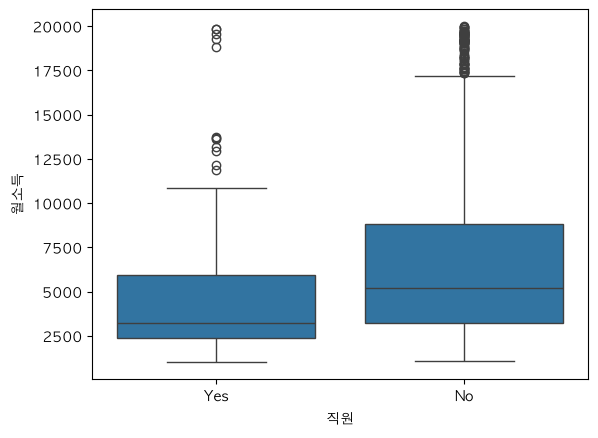

In [5]:
# 2. 이직한 직원(Yes)과 잔류한 직원(No)의 월소득(MonthlyIncome) 평균 및 분포(Boxplot)에는 어떤 차이가 있는지 결과를 분석하고 그래프로 나타내고 서술하세요,

# - 이직 집단(Yes)과 잔류 집단(No)의 평균 월소득을 각각 산출하고, 소득의 분포와 이상치를 한눈에 파악할 수 있는 그래프를 생성하세요.


sns.boxplot(data=promo_df, y="MonthlyIncome", x="Attrition")
plt.ylabel("월소득")
plt.xlabel("직원")
plt.show()

In [6]:

# 3. 마지막 승진 후 기간(YearsSinceLastPromotion)이 길어질수록 이직률이 높아진다는 가설이 맞는지 결과를 분석하고 그래프로 나타내고 서술하세요,

# - 마지막 승진 후 기간별 이직률(%)을 집계하고, 변화 흐름을 파악하기 적합한 그래프를 생성하세요.
# plt.plot(kind="bar")

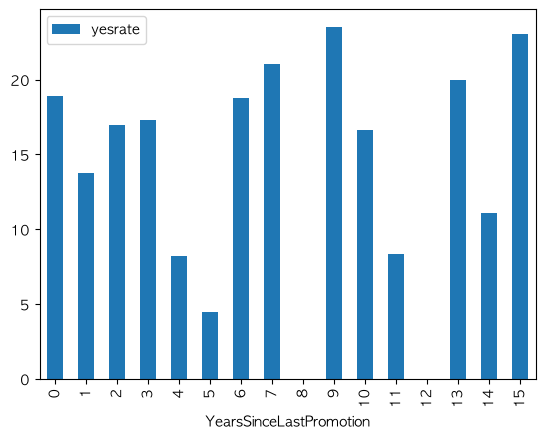

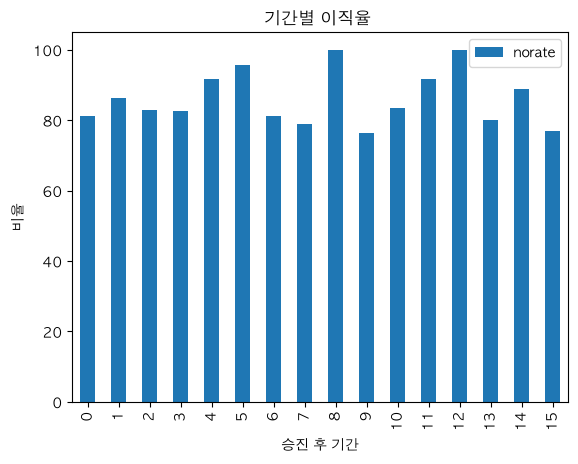

In [52]:
df = promo_df.groupby("YearsSinceLastPromotion")["Attrition"].agg(
    yesrate = lambda x: (x =="Yes").mean() * 100,
    norate = lambda x: (x =="No").mean() * 100
)
df


df.plot(y = "yesrate", kind="bar", legend=True)
df.plot(y = "norate", kind="bar", legend=True)
plt.title("기간별 이직율 ")
plt.xlabel("승진 후 기간")
plt.ylabel("비율")

plt.show()



In [14]:

# 4. 워라밸 만족도(WorkLifeBalance: 1~4점) 점수별 이직률을 구하고, 워라밸이 낮을 때(1점)의 이직 위험도를 분석하고 그래프로 나타내고 서술하세요,

# - WorkLifeBalance 척도(1점: Bad ~ 4점: Best)별 이직률(%)을 구하고, 그룹 간 크기 비교에 적勣합한 그래프를 생성하세요.

In [23]:
promo_df


,Attrition,Age,Gender,MaritalStatus,Education,Department,JobRole,BusinessTravel,OverTime,DistanceFromHome,MonthlyIncome,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,YearsAtCompany,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,PerformanceRating,YearsSinceLastPromotion
0,Yes,41,Female,Single,2,Sales,Sales Executive,Travel_Rarely,Yes,1,5993,11,0,8,6,2,4,1,3,0
1,No,49,Male,Married,1,Research & Development,Research Scientist,Travel_Frequently,No,8,5130,23,1,10,10,3,2,3,4,1
2,Yes,37,Male,Single,2,Research & Development,Laboratory Technician,Travel_Rarely,Yes,2,2090,15,0,7,0,4,3,3,3,0
3,No,33,Female,Married,4,Research & Development,Research Scientist,Travel_Frequently,Yes,3,2909,11,0,8,8,4,3,3,3,3
4,No,27,Male,Married,1,Research & Development,Laboratory Technician,Travel_Rarely,No,2,3468,12,1,6,2,1,2,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,No,36,Male,Married,2,Research & Development,Laboratory Technician,Travel_Frequently,No,23,2571,17,1,17,5,3,4,3,3,0
1466,No,39,Male,Married,1,Research & Development,Healthcare Representative,Travel_Rarely,No,6,9991,15,1,9,7,4,1,3,3,1
1467,No,27,Male,Married,3,Research & Development,Manufacturing Director,Travel_Rarely,Yes,4,6142,20,1,6,6,2,2,3,4,0
1468,No,49,Male,Married,3,Sales,Sales Executive,Travel_Frequently,No,2,5390,14,0,17,9,4,2,2,3,0


In [55]:
wor_df = promo_df.groupby("WorkLifeBalance")["Attrition"].apply(lambda x: (x=="Yes").mean()).reset_index() 
wor_df

,WorkLifeBalance,Attrition
0,1,0.312500
1,2,0.168605
2,3,0.142217
3,4,0.176471


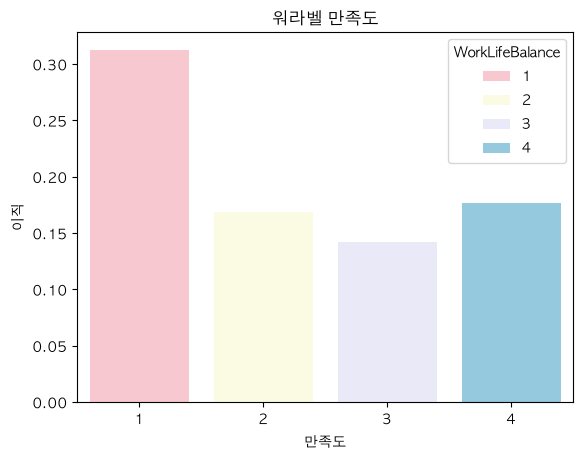


    [결론]
    만족도 1점인 직원은 이직율 3%로 가장 놑고 약 두배정도 많다   
    2~4 점인 직원은 이직율 각 약13~16% 사이로 확인이 된다   
    따라서 워라벨이 지켜지지 않을 경우 이직할 확율이 높아진다고 판단된다 



In [51]:
sns.barplot(data=wor_df ,x= "WorkLifeBalance", y= "Attrition", hue="WorkLifeBalance" ,palette=["pink", "lightyellow", "lavender", "skyblue" ])
plt.title("워라벨 만족도")
plt.xlabel("만족도")
plt.ylabel("이직")
plt.show()
print(
"""
    [결론]
    만족도 1점인 직원은 이직율 3%로 가장 놑고 약 두배정도 많다   
    2~4 점인 직원은 이직율 각 약13~16% 사이로 확인이 된다   
    따라서 워라벨이 지켜지지 않을 경우 이직할 확율이 높아진다고 판단된다 
"""
)
